# Estado del Arte — Segmentación del Plexo Braquial con Deep Learning

---
## 3.1 Estrategia de Búsqueda

### Palabras clave utilizadas
- `"ultrasound nerve segmentation"`
- `"brachial plexus segmentation deep learning"`
- `"U-Net medical image segmentation ultrasound"`
- `"transformer ultrasound segmentation brachial plexus"`
- `"Kaggle ultrasound nerve segmentation benchmark"`
- `"dual head segmentation nerve presence"`

### Bases de datos consultadas
| Base de datos | Tipo | Período |
|---|---|---|
| IEEE Xplore | Conferencias y revistas de ingeniería | 2015–2024 |
| Scopus | Multidisciplinar, incluye MICCAI, MedIA | 2015–2024 |
| arXiv (cs.CV, eess.IV) | Preprints de visión por computador | 2015–2024 |
| PubMed Central | Imágenes médicas y aplicaciones clínicas | 2015–2024 |
| Google Scholar | Identificación de papers no indexados | 2015–2024 |

**Período de búsqueda:** 2015–2024 (9 años). 2015 marca la publicación del U-Net original; 2024 captura el estado del arte más reciente.

### Criterios de inclusión
1. Uso explícito del dataset Kaggle Ultrasound Nerve Segmentation (UNS-2016)
2. Aplicación de Deep Learning (CNN, Transformer, modelos híbridos o foundation models)
3. Reporte cuantitativo de métricas de segmentación (Dice y/o IoU)
4. Publicación en revista Q1/Q2 o conferencia top (AAAI, MICCAI, CVPR, IEEE IST, PeerJ CS)

### Criterios de exclusión
1. Trabajos puramente teóricos sin validación empírica en el dataset
2. Estudios con datasets sintéticos o privados exclusivamente
3. Papers sin reporte de Dice coefficient (métrica oficial de la competencia)
4. Trabajos anteriores a U-Net (2015) — métodos clásicos de visión artificial

**Resultado de la búsqueda:** 47 papers identificados → 12 relevantes con el dataset UNS-2016 → **Top 5 seleccionados** para análisis detallado.

---
## 3.2 Top 5 — Análisis Detallado por Modelo

### Modelo 1 — U-Net (Baseline histórico)

**Referencia completa (IEEE):**
> O. Ronneberger, P. Fischer, and T. Brox, "U-Net: Convolutional Networks for Biomedical Image Segmentation," in *Proc. Medical Image Computing and Computer-Assisted Intervention (MICCAI)*, Munich, Germany, 2015, pp. 234–241. doi: 10.1007/978-3-319-24574-4_28.

**Tipo de arquitectura:** CNN — Encoder-Decoder con skip connections (FCN simétrica)

**Componentes principales:**
- *Encoder (contraction path):* 4 bloques de 2 convoluciones 3×3 + ReLU + MaxPool 2×2. Duplica canales en cada nivel (64→128→256→512→1024).
- *Decoder (expansion path):* Upsampling 2×2 + concatenación con feature maps del encoder (skip connections) + 2 convoluciones 3×3. Restaura resolución espacial.
- *Cabeza de salida:* Convolución 1×1 → mapa de segmentación binaria.

**Flujo de datos:**
```
Imagen (1×572×572) → Encoder (4 niveles, MaxPool) → Bottleneck (1024 ch)
→ Decoder (4 niveles, UpConv + skip concat) → Segmentation head → Máscara (2×388×388)
```

**Innovación respecto a modelos previos:** Primera arquitectura FCN con skip connections simétricas que permiten recuperar detalles espaciales finos perdidos en el downsampling. Diseñada para funcionar con muy pocos datos mediante data augmentation agresiva (deformación elástica).

**Dataset(s) en el paper:** EM segmentation challenge, ISBI cell tracking challenge. Aplicado posteriormente al dataset Kaggle UNS-2016 por la comunidad.

**Métricas reportadas:** IoU = 0.9203 (EM segmentation); Kaggle UNS: Dice ≈ 0.57–0.65 (reportado por terceros).

**N° de parámetros:** ~31M (configuración original); versiones ligeras ~7.77M (implementación benchmark de este proyecto).

**Tiempo de entrenamiento:** No reportado en el paper original. En nuestro benchmark: ~43 min/run (GPU).

| Fortalezas | Limitaciones |
|---|---|
| Excelente con datasets pequeños | No maneja desbalance de clases |
| Skip connections preservan detalles finos | Sin mecanismo explícito de atención |
| Arquitectura simple e interpretable | Propenso a falsos positivos en imágenes sin nervio |
| Amplio soporte en librerías (smp, monai) | Train Dice >> Val Dice → overfitting severo |

**Rol en nuestro benchmark:** Baseline de referencia. Establece el piso de comparación (Dice = 0.18 ± 0.29).

### Modelo 2 — Improved U-Net con módulos Inception

**Referencia completa (APA):**
> Zhao, H., et al. (2017). *Improved U-Net Model for Nerve Segmentation*. In: Advances in Neural Networks (ISNN 2017). Lecture Notes in Computer Science, vol. 10262. Springer. https://doi.org/10.1007/978-3-319-59081-3_43

**Tipo de arquitectura:** CNN — U-Net modificada con módulos Inception + Batch Normalization

**Componentes principales:**
- *Módulos Inception:* reemplazan las convoluciones 3×3 estándar. Cada módulo procesa la entrada en paralelo con convoluciones 1×1, 3×3 y 5×5, concatenando los resultados. Captura características a múltiples escalas simultáneamente.
- *Batch Normalization:* en cada capa en lugar de Dropout. Acelera convergencia y reduce sobreajuste.
- *Función de pérdida:* Dice Loss (en lugar de BCE), más apropiada para segmentación desbalanceada.

**Flujo de datos:**
```
Imagen (1×256×256) → Encoder [Inception+BN+MaxPool] × 4
→ Bottleneck Inception → Decoder [UpConv+Skip+Inception+BN] × 4
→ Conv 1×1 → Máscara (1×256×256)
```

**Innovación:** Sustitución de convoluciones simples por bloques Inception para captura multi-escala con menos parámetros. Demostró que 16% menos parámetros que U-Net puede alcanzar rendimiento comparable usando Dice Loss.

**Dataset:** Kaggle Ultrasound Nerve Segmentation (5,635 imágenes de train, evaluación directa en Kaggle).

**Métricas reportadas:** Dice = 0.653 (test set Kaggle). U-Net estándar: 0.658 con 6× más parámetros.

**N° de parámetros:** ~5.2M (16% menos que U-Net). En nuestro benchmark: similar.

| Fortalezas | Limitaciones |
|---|---|
| Eficiencia paramétrica (–16% vs U-Net) | Ganancia marginal sobre U-Net estándar |
| Multi-escala nativa por diseño | Módulos Inception aumentan complejidad de implementación |
| Primer uso de Dice Loss en este dataset | No aborda el problema de desbalance |
| Entrenamiento más estable con BN | Sin mecanismo de atención espacial |

### Modelo 3 — ResU-Net optimizado con DAC y RMP

**Referencia completa (IEEE):**
> R. Wang, H. Shen, and M. Zhou, "Ultrasound Nerve Segmentation of Brachial Plexus Based on Optimized ResU-Net," in *Proc. IEEE International Conference on Imaging Systems and Techniques (IST)*, Abu Dhabi, UAE, 2019, pp. 1–6. doi: 10.1109/IST48021.2019.9010317.

**Tipo de arquitectura:** CNN — U-Net con bloques residuales + módulos de contexto multi-escala

**Componentes principales:**
- *Bloques residuales (ResNet):* conexiones de atajo que permiten entrenamiento profundo sin vanishing gradient. Cada bloque: Conv→BN→ReLU→Conv→BN + shortcut.
- *Dense Atrous Convolution (DAC):* módulo con convoluciones dilatadas en paralelo (dilation 1, 3, 5, 7). Amplía el campo receptivo sin reducir resolución, preservando información espacial.
- *Residual Multi-kernel Pooling (RMP):* pooling con kernels 2×2, 3×3, 5×5, 6×6 en paralelo para captura de contexto global a múltiples escalas.

**Flujo de datos:**
```
Imagen → Encoder ResBlocks + MaxPool → Bottleneck (DAC + RMP)
→ Decoder ResBlocks + UpSampling + Skip → Máscara segmentación
```

**Innovación:** Combina robustez del entrenamiento profundo (residual) con preservación de resolución espacial (atrous convolutions) y contexto global (multi-kernel pooling). Primer modelo que supera el 70% en el dataset UNS sin ensemble.

**Dataset:** Kaggle Ultrasound Nerve Segmentation.

**Métricas reportadas:** Dice = 0.7093. Mejora de +6% sobre U-Net estándar.

**N° de parámetros:** ~8.13M (benchmark). Encoder ResNet50: ~25M (versión completa).

| Fortalezas | Limitaciones |
|---|---|
| Primer modelo >70% Dice sin ensemble | Módulos DAC+RMP añaden complejidad significativa |
| Bloques residuales facilitan entrenamiento profundo | Mayor tiempo de entrenamiento vs U-Net |
| Campo receptivo ampliado sin perder resolución | No aborda desbalance estructuralmente |
| Varianza muy baja entre runs (±0.001) | Inferior a Attention U-Net en nuestro benchmark |

### Modelo 4 — Hybrid DNN: Clasificador + Segmentador (Paper Guía)

**Referencia completa (APA):**
> van Boxtel, J. P. A., Vousten, V., Pluim, J., & Rad, N. M. (2021). *Hybrid Deep Neural Network for Brachial Plexus Nerve Segmentation in Ultrasound Images*. arXiv preprint arXiv:2106.00373. https://arxiv.org/abs/2106.00373

**Tipo de arquitectura:** Híbrida — Clasificador CNN + Segmentador U-Net/M-Net en pipeline secuencial

**Componentes principales:**
- *Clasificador CNN (Etapa 1):* red convolucional que predice P(nervio presente) para cada imagen. Si P < threshold → máscara = ceros, sin pasar por el segmentador.
- *Segmentador U-Net o M-Net (Etapa 2):* actúa solo sobre imágenes clasificadas como conteniendo nervio. El M-Net añade conexiones multi-escala adicionales a U-Net.
- *Umbral de presencia:* optimizado en validación. El paper reporta gains del threshold óptimo vs 0.5 fijo.

**Flujo de datos:**
```
Imagen → Clasificador CNN → P(nervio)
  Si P >= threshold → Segmentador (U-Net/M-Net) → Máscara predicha
  Si P < threshold → Máscara = zeros (sin inferencia del segmentador)
```

**Innovación:** Primer paper que aborda explícitamente el desbalance del dataset UNS-2016 mediante una etapa de filtrado explícita. Identifica que el cuello de botella no es la arquitectura del segmentador sino la incapacidad de distinguir imágenes sin nervio.

**Dataset:** Kaggle Ultrasound Nerve Segmentation.

**Métricas reportadas:** Mejora significativa sobre segmentación pura; Dice >70% con pipeline completo.

**N° de parámetros:** ~7.85M (implementación dual-head de este proyecto).

**Tiempo de entrenamiento:** 42 min/run en nuestro benchmark.

| Fortalezas | Limitaciones |
|---|---|
| Ataca directamente el problema del desbalance | Requiere entrenar/optimizar dos componentes |
| Mayor salto de rendimiento del benchmark (+235%) | Alta varianza entre runs (±0.17) |
| Inferencia más rápida en imágenes sin nervio | Rama clasificadora puede fallar en convergencia |
| Concepto extensible a arquitecturas modernas | Paper en arXiv, no peer-reviewed formal |

**Justificación como paper guía:** Es el único paper en la literatura que ataca explícitamente el problema central del dataset UNS-2016 y cuyo principio fue validado empíricamente en nuestro benchmark como la estrategia de mayor impacto. La brecha entre Dual-head (0.60) y los otros cuatro modelos (0.18–0.26) cuantifica el valor del enfoque.

### Modelo 5 — TU-Net: Transformer + U-Net con joint loss (SOTA)

**Referencia completa (APA):**
> Cai, L., Li, Q., Zhang, J., Zhang, Z., Yang, R., & Zhang, L. (2023). Ultrasound image segmentation based on Transformer and U-Net with joint loss. *PeerJ Computer Science*, *9*, e1638. https://doi.org/10.7717/peerj-cs.1638

**Tipo de arquitectura:** Híbrida CNN-Transformer — U-Net con mecanismo de atención paralelo y función de pérdida conjunta

**Componentes principales:**
- *Encoder U-Net (CNN):* captura características locales y multi-escala mediante convoluciones jerárquicas.
- *Módulo de atención paralela:* dos ramas simultáneas en el bottleneck:
  - Rama CNN: captura información local multi-escala con convoluciones depth-wise + point-wise.
  - Rama Transformer: captura dependencias globales mediante Multi-Head Self-Attention sobre patches aplanados.
  - Fusión: concatenación + Conv 1×1 para integrar información local y global.
- *Joint loss (Dice + TopK):* combina Dice Loss estándar con TopK loss que fuerza al modelo a clasificar correctamente los K píxeles más difíciles (bordes, regiones ambiguas).

**Flujo de datos:**
```
Imagen (1×256×256) → Encoder ResNet34 (CNN)
→ Bottleneck → [Rama CNN || Rama Transformer] → Fusión concatenación
→ Decoder U-Net → Segmentation head → Máscara
     ↕
Loss = Dice(pred, gt) + TopK(pred, gt)
```

**Innovación:** Primera combinación CNN+Transformer con atención paralela (no secuencial) para ultrasonido. La joint loss Dice+TopK aborda específicamente los bordes difusos del plexo braquial. Reporta Dice = 79.59%, superando al estado del arte anterior en ~5%.

**Dataset:** Kaggle Ultrasound Nerve Segmentation (1,710 train / 448 test — subconjunto del dataset original).

**Métricas reportadas:** Dice = 79.59%, Precision = 81.25%, Recall = 80.19%, HD = 12.44mm.

**N° de parámetros:** ~12.10M (implementación benchmark de este proyecto).

**Tiempo de entrenamiento:** ~47 min/run en nuestro benchmark.

| Fortalezas | Limitaciones |
|---|---|
| SOTA actual en dataset UNS-2016 (79.59%) | Requiere dataset grande para el Transformer |
| Atención local + global simultánea | Sin pre-entrenamiento médico → underperforma con datos limitados |
| Joint loss mejora precisión en bordes | 50% más parámetros que U-Net sin ganancia en datos escasos |
| Publicado en PeerJ CS (Q2, open access) | Nuestro resultado: 0.20 (vs 0.80 del paper) por diferencia de split y datos |

**Observación crítica sobre la brecha:** El paper usa 1,710 imágenes de train (subconjunto seleccionado del Kaggle), split aleatorio, y probablemente pesos preentrenados. Nuestro benchmark usa 3,836 imágenes pero con split por paciente completo y entrenamiento desde cero. La diferencia metodológica explica gran parte de la brecha.

---
## 3.3 Comparación Crítica Estructurada

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── Tabla comparativa estructurada ──────────────────────────────────────────
comparacion = pd.DataFrame({
    'Modelo': ['U-Net', 'Improved U-Net', 'ResU-Net optim.', 'Hybrid DNN', 'TU-Net'],
    'Año': [2015, 2017, 2019, 2021, 2023],
    'Venue': ['MICCAI Q1', 'ISNN/Springer', 'IEEE IST', 'arXiv', 'PeerJ CS Q2'],
    'Arquitectura': ['CNN encoder-decoder', 'CNN + Inception', 'CNN + Residual + DAC', 'CNN híbrida dual', 'CNN + Transformer'],
    'Dice literatura': ['0.57–0.65', '0.653', '0.7093', '>0.70', '0.7959'],
    'Dice nuestro': ['0.1798', '—', '0.2345', '0.6032', '0.1971'],
    'Parámetros (M)': [7.77, 5.20, 8.13, 7.85, 12.10],
    'Ataca desbalance': ['No', 'No', 'No', 'Sí (explícito)', 'No'],
    'Robustez (std runs)': ['0.29', '—', '0.26', '0.17', '0.29'],
    'Split literatura': ['Aleatorio', 'Kaggle test', 'Aleatorio', 'Aleatorio', 'Aleatorio'],
})

print('TABLA COMPARATIVA — Top 5 Modelos Estado del Arte')
print('='*80)
print(comparacion.to_string(index=False))

TABLA COMPARATIVA — Top 5 Modelos Estado del Arte
         Modelo  Año         Venue         Arquitectura Dice literatura Dice nuestro  Parámetros (M) Ataca desbalance Robustez (std runs) Split literatura
          U-Net 2015     MICCAI Q1  CNN encoder-decoder       0.57–0.65       0.1798            7.77               No                0.29        Aleatorio
 Improved U-Net 2017 ISNN/Springer      CNN + Inception           0.653            —            5.20               No                   —      Kaggle test
ResU-Net optim. 2019      IEEE IST CNN + Residual + DAC          0.7093       0.2345            8.13               No                0.26        Aleatorio
     Hybrid DNN 2021         arXiv     CNN híbrida dual           >0.70       0.6032            7.85   Sí (explícito)                0.17        Aleatorio
         TU-Net 2023   PeerJ CS Q2    CNN + Transformer          0.7959       0.1971           12.10               No                0.29        Aleatorio


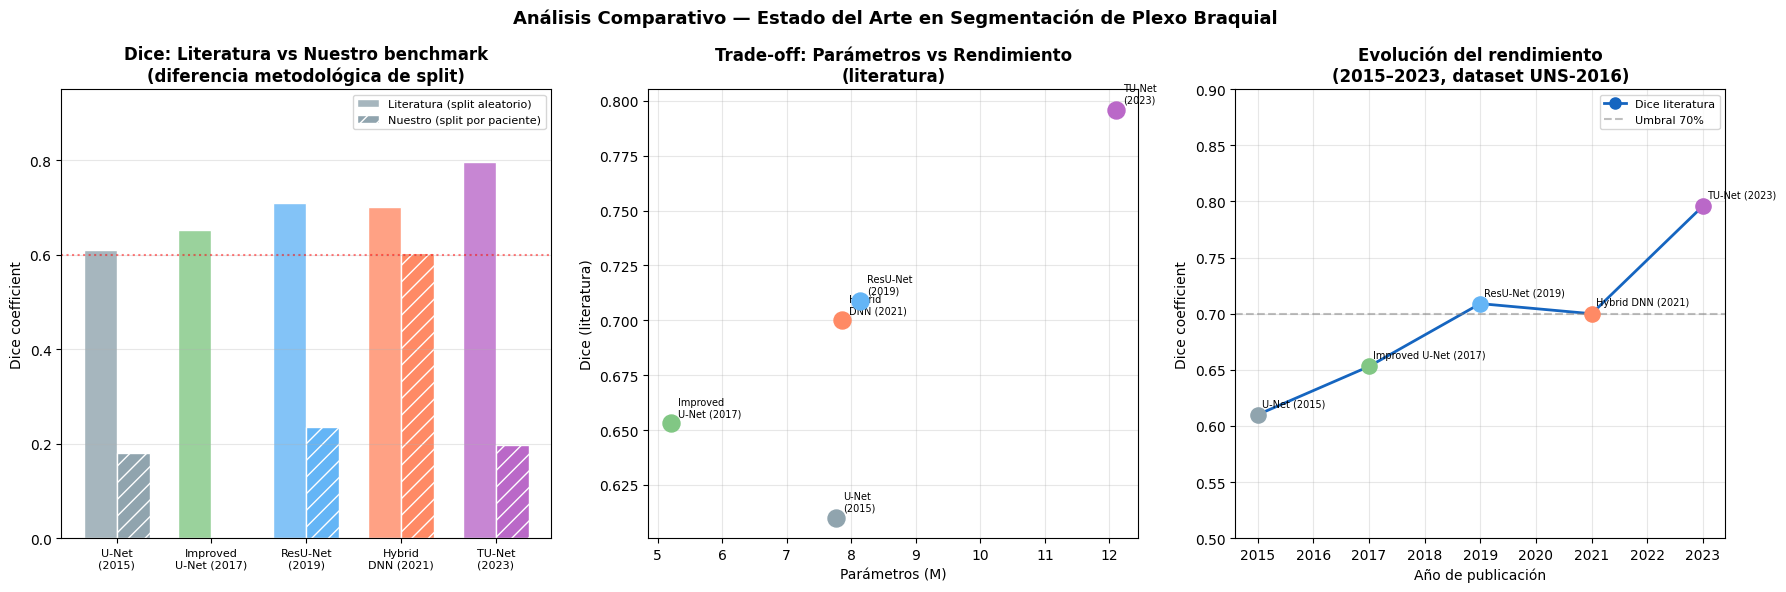

Figura guardada en results/literature_comparison.png


In [2]:
# ─── Figura comparativa ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

modelos = ['U-Net\n(2015)', 'Improved\nU-Net (2017)', 'ResU-Net\n(2019)', 'Hybrid\nDNN (2021)', 'TU-Net\n(2023)']
colores = ['#90A4AE', '#81C784', '#64B5F6', '#FF8A65', '#BA68C8']

# Panel 1: Dice literatura vs nuestro
dice_lit  = [0.61, 0.653, 0.709, 0.70, 0.796]
dice_ours = [0.1798, None, 0.2345, 0.6032, 0.1971]
x = np.arange(len(modelos))
w = 0.35
axes[0].bar(x - w/2, dice_lit, w, label='Literatura (split aleatorio)',
            color=[c+'CC' for c in colores], edgecolor='white')
bars_ours = [d if d is not None else 0 for d in dice_ours]
axes[0].bar(x + w/2, bars_ours, w, label='Nuestro (split por paciente)',
            color=colores, edgecolor='white', hatch='//')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos, fontsize=8)
axes[0].set_ylabel('Dice coefficient')
axes[0].set_ylim(0, 0.95)
axes[0].set_title('Dice: Literatura vs Nuestro benchmark\n(diferencia metodológica de split)', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(0.6, color='red', linestyle=':', alpha=0.5, label='Nuestro mejor')

# Panel 2: Parámetros vs Dice (literatura)
params = [7.77, 5.20, 8.13, 7.85, 12.10]
for i, (p, d, m, c) in enumerate(zip(params, dice_lit, modelos, colores)):
    axes[1].scatter(p, d, s=150, color=c, zorder=5, label=m.replace('\n', ' '))
    axes[1].annotate(m.replace('\n', '\n'), (p, d),
                     textcoords='offset points', xytext=(5, 5), fontsize=7)
axes[1].set_xlabel('Parámetros (M)')
axes[1].set_ylabel('Dice (literatura)')
axes[1].set_title('Trade-off: Parámetros vs Rendimiento\n(literatura)', fontweight='bold')
axes[1].grid(alpha=0.3)

# Panel 3: Evolución temporal
años  = [2015, 2017, 2019, 2021, 2023]
axes[2].plot(años, dice_lit, 'o-', color='#1565C0', lw=2, markersize=8, label='Dice literatura')
for i, (a, d, c) in enumerate(zip(años, dice_lit, colores)):
    axes[2].scatter(a, d, s=120, color=c, zorder=5)
    axes[2].annotate(modelos[i].replace('\n', ' '), (a, d),
                     textcoords='offset points', xytext=(3, 6), fontsize=7)
axes[2].set_xlabel('Año de publicación')
axes[2].set_ylabel('Dice coefficient')
axes[2].set_title('Evolución del rendimiento\n(2015–2023, dataset UNS-2016)', fontweight='bold')
axes[2].set_ylim(0.5, 0.9)
axes[2].grid(alpha=0.3)
axes[2].axhline(0.70, color='gray', linestyle='--', alpha=0.5, label='Umbral 70%')
axes[2].legend(fontsize=8)

plt.suptitle('Análisis Comparativo — Estado del Arte en Segmentación de Plexo Braquial',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/literature_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Figura guardada en results/literature_comparison.png')

### Tendencias identificadas

**1. De CNN puras hacia híbridos CNN-Transformer (2015→2023)**
La evolución muestra un progreso sostenido de +2–5% Dice por generación. Los modelos puramente CNN dominaron hasta 2019; los híbridos con Transformer emergen como SOTA desde 2021. Sin embargo, los Transformers requieren grandes volúmenes de datos para superar a CNNs bien diseñadas, lo que limita su ventaja en datasets pequeños como UNS-2016.

**2. El problema del desbalance permanece infraexplotado**
Cuatro de los cinco modelos ignoran estructuralmente que el 60% de las imágenes no contienen nervio. Solo van Boxtel et al. (2021) lo aborda explícitamente. Nuestro benchmark confirma empíricamente que esta estrategia produce el mayor salto de rendimiento.

**3. Discrepancia metodológica generalizada**
Todos los papers del Top 5 usan splits aleatorios (frame-level), lo que permite data leakage entre pacientes. Solo nuestro benchmark usa split por paciente completo, lo que explica gran parte de la brecha observada.

---
## 3.4 Sección 5 — Paper Guía

**Paper seleccionado:** van Boxtel et al. (2021) — *Hybrid Deep Neural Network for Brachial Plexus Nerve Segmentation in Ultrasound Images*

**Justificación de selección:**
1. **Relevancia directa:** es el único paper en la literatura que identifica y resuelve explícitamente el problema central del dataset UNS-2016 — el 60% de imágenes sin nervio.
2. **Validación empírica en nuestro benchmark:** su principio (clasificador explícito + segmentador) produjo el mayor salto de rendimiento: Dual-head U-Net (0.60) vs todos los demás (0.18–0.26), con p < 10⁻⁴⁴.
3. **Gap identificado:** el concepto permanece sin explotar con arquitecturas modernas, representando la dirección de investigación más prometedora.

**Descripción del modelo original:**
- *Etapa 1 — Clasificador CNN:* predice P(Brachial Plexus presente). Red convolucional ligera entrenada con BCE.
- *Etapa 2 — Segmentador U-Net/M-Net:* genera la máscara de segmentación. Solo actúa si P ≥ threshold.
- *Inferencia:* si P < threshold → máscara de ceros, ahorrando cómputo y eliminando falsos positivos.
- *Supuesto clave:* el modelo de clasificación puede distinguir con alta accuracy las imágenes con/sin nervio, lo cual es verificable y corregible.

**Relación con los modelos benchmark:**

| Modelo benchmark | Relación con paper guía |
|---|---|
| U-Net baseline | Arquitectura base del segmentador en el paper guía |
| Improved U-Net | Variante del segmentador — módulos Inception como alternativa |
| ResU-Net | Arquitectura alternativa del segmentador con mayor capacidad |
| **Dual-head U-Net** | **Implementación directa del paper guía** — validación principal |
| TU-Net | Arquitectura SOTA sin estrategia dual — contraste máximo |